# 1. Load dữ liệu

In [1]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.stats import mannwhitneyu

## 1.1. Đọc dữ liệu items

In [2]:
items_lf = pl.scan_parquet("items.parquet")

items_lf.collect().schema

Schema([('item_id', String),
        ('price', Decimal(precision=38, scale=4)),
        ('category_l1', String),
        ('category_l2', String),
        ('category_l3', String),
        ('category', String),
        ('brand', String),
        ('manufacturer', String),
        ('description', String),
        ('sale_status', Int32),
        ('size', String)])

In [3]:
items_lf.head().collect()

item_id,price,category_l1,category_l2,category_l3,category,brand,manufacturer,description,sale_status,size
str,"decimal[38,4]",str,str,str,str,str,str,str,i32,str
"""0008040000046""",115000.0000,"""Đồ chơi & Sách""","""1Y+""","""Học tập và phát triển tư duy""","""Siêu nhân, robot""","""WinWinToys""","""Không xác định""","""Robo Luồn thun Winwintoys có h…",0,"""Không xác định"""
"""0502020000004""",99000.0000,"""Babycare""","""Bình sữa, phụ kiện""","""Núm ty""","""Núm ty Dr Brown""","""Dr.Brown's""","""Không xác định""","""Không xác định""",0,"""Không xác định"""
"""0007010000886""",102000.0000,"""Babycare""","""Bình sữa, phụ kiện""","""Núm ty""","""Núm ty Pigeon""","""Pigeon""","""Không xác định""","""Với hơn 60 năm qua, trải qua r…",0,"""Không xác định"""
"""0502020340030""",228000.0000,"""Babycare""","""Bình sữa, phụ kiện""","""Phụ kiện bình sữa""","""Bình, túi ủ sữa""","""KUKU""","""Không xác định""","""Bình ủ sữa của KuKu của Đài Lo…",0,"""Không xác định"""
"""0012050000007""",59000.0000,"""Thời trang""","""Cơ cấu hàng cũ""","""Đồ bầu""","""Áo ngực bầu""","""Không xác định""","""Không xác định""","""Không xác định""",0,"""Không xác định"""


## 1.2. Đọc dữ liệu transactions_202411-to-202412

In [4]:
trans24_lf = pl.scan_parquet("transactions-202411-to-202412.parquet")

In [5]:
trans24_lf.collect().schema

Schema([('customer_id', Int32),
        ('item_id', String),
        ('price', Decimal(precision=38, scale=4)),
        ('channel', String),
        ('payment', String),
        ('updated_date', Datetime(time_unit='us', time_zone=None)),
        ('location', Int32),
        ('quantity', Int32)])

In [6]:
trans24_lf.head().collect()

customer_id,item_id,price,channel,payment,updated_date,location,quantity
i32,str,"decimal[38,4]",str,str,datetime[μs],i32,i32
6680595,"""6033000000053""",169000.0000,"""In-Store""","""VietQR""",2024-12-29 17:37:10.410,181,1
3256247,"""4562000000101""",169000.0000,"""In-Store""","""VietQR""",2024-12-30 18:34:51.117,79,1
8180719,"""3500000000005""",49000.0000,"""In-Store""","""VietQR""",2024-12-22 16:01:47.987,1002,1
2079076,"""3500000000004""",49000.0000,"""In-Store""","""VietQR""",2024-12-16 18:30:58.480,242,1
7311623,"""3460000000009""",49500.0000,"""In-Store""","""VietQR""",2024-12-14 19:41:23.670,972,1


## 1.3. Đọc dữ liệu transactions_2025-12

In [7]:
trans25_lf = pl.scan_parquet("transactions-2025-12.parquet")

In [8]:
trans25_lf.collect().schema


Schema([('customer_id', Int32),
        ('item_id', String),
        ('price', Decimal(precision=38, scale=4)),
        ('channel', String),
        ('payment', String),
        ('updated_date', Datetime(time_unit='us', time_zone=None)),
        ('location', Int32),
        ('quantity', Int32)])

In [9]:
trans25_lf.head().collect()

customer_id,item_id,price,channel,payment,updated_date,location,quantity
i32,str,"decimal[38,4]",str,str,datetime[μs],i32,i32
8861340,"""0151000000003""",1625000.0000,"""In-Store""","""Tiền mặt""",2025-12-12 16:44:47.793,385,1
8680587,"""5074000000001""",139000.0000,"""SPE""","""Tiền mặt""",2025-12-01 10:28:50.830,1063,1
8220170,"""5856000000001""",480000.0000,"""SPE""","""Tiền mặt""",2025-12-23 09:20:27.653,416,1
7496264,"""6768000000002""",316200.0000,"""SPE""","""Tiền mặt""",2025-12-23 09:06:39.980,336,3
9170522,"""6904000000002""",840000.0000,"""SPE""","""Không xác định""",2025-12-23 09:24:55.640,601,1


# 2. Gộp dữ liệu giao dịch

In [10]:
transactions_lf = pl.concat([
    trans24_lf,
    trans25_lf
])

print(transactions_lf.select(pl.len()).collect().item())

9835894


# 3. Join với bảng sản phẩm
- Đổi tên cột price trong bảng items.
    - transactions.price: giá tại thời điểm giao dịch
    - items.price: giá niêm yết sản phẩm

In [11]:
items_lf = items_lf.rename({
    "price": "item_price"
})

df_lf = transactions_lf.join(
    items_lf,
    on="item_id",
    how="left"
)

df_lf.collect().schema


Schema([('customer_id', Int32),
        ('item_id', String),
        ('price', Decimal(precision=38, scale=4)),
        ('channel', String),
        ('payment', String),
        ('updated_date', Datetime(time_unit='us', time_zone=None)),
        ('location', Int32),
        ('quantity', Int32),
        ('item_price', Decimal(precision=38, scale=4)),
        ('category_l1', String),
        ('category_l2', String),
        ('category_l3', String),
        ('category', String),
        ('brand', String),
        ('manufacturer', String),
        ('description', String),
        ('sale_status', Int32),
        ('size', String)])

### - Loại bỏ các cột:
- customer_id, channel, payment, location, branch, manufacturer, description, size

In [12]:
df_lf = df_lf.select([
    "item_id",
    "price",
    "item_price",
    "quantity",
    "updated_date",
    "category_l1",
    "category_l2",
    "category_l3",
    "category",
    "sale_status"
])

df_lf.head().collect()

item_id,price,item_price,quantity,updated_date,category_l1,category_l2,category_l3,category,sale_status
str,"decimal[38,4]","decimal[38,4]",i32,datetime[μs],str,str,str,str,i32
"""6033000000053""",169000.0000,219000.0000,1,2024-12-29 17:37:10.410,"""Thời trang""","""Thời trang bé gái""","""Bộ bé gái""","""Bộ bé gái Animo""",0
"""4562000000101""",169000.0000,199000.0000,1,2024-12-30 18:34:51.117,"""Thời trang""","""Thời trang bé gái""","""Bodysuit bé gái""","""Bodysuit bé gái đùi""",0
"""3500000000005""",49000.0000,79000.0000,1,2024-12-22 16:01:47.987,"""Thời trang""","""Quần áo & Phụ kiện sơ sinh""","""Phụ kiện cho bé""","""Set 2 đôi vớ""",0
"""3500000000004""",49000.0000,79000.0000,1,2024-12-16 18:30:58.480,"""Thời trang""","""Quần áo & Phụ kiện sơ sinh""","""Phụ kiện cho bé""","""Set 2 đôi vớ""",0
"""3460000000009""",49500.0000,129000.0000,1,2024-12-14 19:41:23.670,"""Thời trang""","""Thời trang bé trai""","""Quần bé trai""","""Quần short bé trai""",1


# 4. Phát hiện và xử lý Missing Data

In [13]:
# các dòng thiếu dữ liệu quan trọng sẽ bị loại bỏ
df_lf = df_lf.filter(
    pl.col("item_id").is_not_null() &
    pl.col("price").is_not_null() &
    pl.col("quantity").is_not_null() &
    pl.col("updated_date").is_not_null()
)
df_lf.head().collect()


item_id,price,item_price,quantity,updated_date,category_l1,category_l2,category_l3,category,sale_status
str,"decimal[38,4]","decimal[38,4]",i32,datetime[μs],str,str,str,str,i32
"""6033000000053""",169000.0000,219000.0000,1,2024-12-29 17:37:10.410,"""Thời trang""","""Thời trang bé gái""","""Bộ bé gái""","""Bộ bé gái Animo""",0
"""4562000000101""",169000.0000,199000.0000,1,2024-12-30 18:34:51.117,"""Thời trang""","""Thời trang bé gái""","""Bodysuit bé gái""","""Bodysuit bé gái đùi""",0
"""3500000000005""",49000.0000,79000.0000,1,2024-12-22 16:01:47.987,"""Thời trang""","""Quần áo & Phụ kiện sơ sinh""","""Phụ kiện cho bé""","""Set 2 đôi vớ""",0
"""3500000000004""",49000.0000,79000.0000,1,2024-12-16 18:30:58.480,"""Thời trang""","""Quần áo & Phụ kiện sơ sinh""","""Phụ kiện cho bé""","""Set 2 đôi vớ""",0
"""3460000000009""",49500.0000,129000.0000,1,2024-12-14 19:41:23.670,"""Thời trang""","""Thời trang bé trai""","""Quần bé trai""","""Quần short bé trai""",1


# 5. Lọc sản phẩm không còn bán

In [14]:
df_lf = df_lf.filter(
    pl.col("sale_status") == 1
)
print(df_lf.select(pl.len()).collect().item())



7933245


# 6. Loại bỏ dữ liệu bất thường

In [15]:
df_lf = df_lf.filter(
    (pl.col("price") > 0) &
    (pl.col("quantity") > 0)
)
print(df_lf.select(pl.len()).collect().item())


7933245


# 7. Phát hiện Outlier

In [16]:
stats = df_lf.select([
    pl.col("quantity").quantile(0.25).alias("q1"),
    pl.col("quantity").quantile(0.75).alias("q3")
]).collect()

q1 = stats["q1"][0]
q3 = stats["q3"][0]

iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

In [17]:
# Lọc Outlier
df_lf = df_lf.filter(
    (pl.col("quantity") >= lower) &
    (pl.col("quantity") <= upper)
)
print(df_lf.select(pl.len()).collect().item())

6361424


# 8. Feature Engineering

## 8.1. Tạo revenue: 
Ý nghĩa: Doanh thu của từng giao dịch.

Cách tính
$$revenue = price \times quantity$$

Mục đích
- Đo lường **giá trị doanh thu thực tế** của từng giao dịch.
- Cho phép tính **tổng doanh thu theo ngày** hoặc theo nhóm sản phẩm.

In [18]:
df_lf = df_lf.with_columns(
    (pl.col("price") * pl.col("quantity")).alias("revenue")
)

## 8.2. Tạo date
Ý nghĩa:
- Ngày giao dịch được trích xuất từ cột updated_date.

Mục đích:

- Chuyển dữ liệu từ timestamp (datetime) sang ngày.
- Cho phép aggregate dữ liệu theo ngày.
- Là biến chính để phân tích time-series doanh số.

In [19]:
df_lf = df_lf.with_columns(
    pl.col("updated_date").dt.date().alias("date")
)
df_lf.head().collect()

item_id,price,item_price,quantity,updated_date,category_l1,category_l2,category_l3,category,sale_status,revenue,date
str,"decimal[38,4]","decimal[38,4]",i32,datetime[μs],str,str,str,str,i32,"decimal[38,4]",date
"""3460000000009""",49500.0000,129000.0000,1,2024-12-14 19:41:23.670,"""Thời trang""","""Thời trang bé trai""","""Quần bé trai""","""Quần short bé trai""",1,49500.0000,2024-12-14
"""4895000000001""",66000.0000,68000.0000,1,2024-12-30 09:03:10.533,"""Thực phẩm cho bé""","""TP từ sữa (bảo quản lạnh)""","""Váng sữa""","""Zott""",1,66000.0000,2024-12-30
"""0020010000210""",33950.0000,36000.0000,1,2024-12-28 18:37:03.107,"""Vệ sinh""","""Băng vệ sinh""","""Băng vệ sinh sau sinh""","""Băng vệ sinh Diana sau sinh""",1,33950.0000,2024-12-28
"""5420000000003""",29000.0000,29000.0000,1,2024-12-25 16:06:13.813,"""Thực phẩm cho bé""","""Cháo ăn dặm""","""Cháo tươi""","""Cây Thị""",1,29000.0000,2024-12-25
"""2406000000005""",585000.0000,635000.0000,1,2024-12-29 08:54:36.970,"""Sữa""","""Enfa""","""Enfa""","""Enfa Step 2""",1,585000.0000,2024-12-29


## 8.3. Tạo holiday feature
- Xác định ngày lễ:
    - 1: ngày lễ (ngày 24/12 và ngày 31/12)
    - 0: ngày thường

In [20]:
df_lf = df_lf.with_columns(
    pl.when(
        (pl.col("date").dt.day() == 24) |
        (pl.col("date").dt.day() == 31)
    )
    .then(1)
    .otherwise(0)
    .alias("is_holiday")
)
df_lf.head().collect()

item_id,price,item_price,quantity,updated_date,category_l1,category_l2,category_l3,category,sale_status,revenue,date,is_holiday
str,"decimal[38,4]","decimal[38,4]",i32,datetime[μs],str,str,str,str,i32,"decimal[38,4]",date,i32
"""3460000000009""",49500.0000,129000.0000,1,2024-12-14 19:41:23.670,"""Thời trang""","""Thời trang bé trai""","""Quần bé trai""","""Quần short bé trai""",1,49500.0000,2024-12-14,0
"""4895000000001""",66000.0000,68000.0000,1,2024-12-30 09:03:10.533,"""Thực phẩm cho bé""","""TP từ sữa (bảo quản lạnh)""","""Váng sữa""","""Zott""",1,66000.0000,2024-12-30,0
"""0020010000210""",33950.0000,36000.0000,1,2024-12-28 18:37:03.107,"""Vệ sinh""","""Băng vệ sinh""","""Băng vệ sinh sau sinh""","""Băng vệ sinh Diana sau sinh""",1,33950.0000,2024-12-28,0
"""5420000000003""",29000.0000,29000.0000,1,2024-12-25 16:06:13.813,"""Thực phẩm cho bé""","""Cháo ăn dặm""","""Cháo tươi""","""Cây Thị""",1,29000.0000,2024-12-25,0
"""2406000000005""",585000.0000,635000.0000,1,2024-12-29 08:54:36.970,"""Sữa""","""Enfa""","""Enfa""","""Enfa Step 2""",1,585000.0000,2024-12-29,0


## 8.4. Tạo weekday feature
- Ý nghĩa: weekday biểu diễn thứ trong tuần của ngày giao dịch
- Doanh số thường phụ thuộc vào ngày trong tuần (ví dụ khách hàng thường mua nhiều vào cuối tuần), giúp để kiểm soát là do holiday nó tăng doanh số hay là weekend (ngày cuối tuần) mới là nguyên nhân gây tăng doanh số. Do đó, mục đích:
    - Kiểm tra hiệu ứng ngày trong tuần
    - Tránh nhầm lẫn giữa holiday effect và weekend effect
- Phương thức .dt.weekday() trả về một số nguyên đại diện cho các ngày trong tuần với quy ước:

    - 1: Thứ Hai (Monday)

    - 2: Thứ Ba (Tuesday)

    - 3: Thứ Tư (Wednesday)

    - 4: Thứ Năm (Thursday)

    - 5: Thứ Sáu (Friday)

    - 6: Thứ Bảy (Saturday)

    - 7: Chủ Nhật (Sunday)

In [21]:
df_lf = df_lf.with_columns(
    pl.col("date").dt.weekday().alias("weekday")
)

df_lf.head().collect()

item_id,price,item_price,quantity,updated_date,category_l1,category_l2,category_l3,category,sale_status,revenue,date,is_holiday,weekday
str,"decimal[38,4]","decimal[38,4]",i32,datetime[μs],str,str,str,str,i32,"decimal[38,4]",date,i32,i8
"""3460000000009""",49500.0000,129000.0000,1,2024-12-14 19:41:23.670,"""Thời trang""","""Thời trang bé trai""","""Quần bé trai""","""Quần short bé trai""",1,49500.0000,2024-12-14,0,6
"""4895000000001""",66000.0000,68000.0000,1,2024-12-30 09:03:10.533,"""Thực phẩm cho bé""","""TP từ sữa (bảo quản lạnh)""","""Váng sữa""","""Zott""",1,66000.0000,2024-12-30,0,1
"""0020010000210""",33950.0000,36000.0000,1,2024-12-28 18:37:03.107,"""Vệ sinh""","""Băng vệ sinh""","""Băng vệ sinh sau sinh""","""Băng vệ sinh Diana sau sinh""",1,33950.0000,2024-12-28,0,6
"""5420000000003""",29000.0000,29000.0000,1,2024-12-25 16:06:13.813,"""Thực phẩm cho bé""","""Cháo ăn dặm""","""Cháo tươi""","""Cây Thị""",1,29000.0000,2024-12-25,0,3
"""2406000000005""",585000.0000,635000.0000,1,2024-12-29 08:54:36.970,"""Sữa""","""Enfa""","""Enfa""","""Enfa Step 2""",1,585000.0000,2024-12-29,0,7


# 9. Aggregate theo ngày
Dữ liệu giao dịch ban đầu được lưu ở cấp độ transaction (từng giao dịch), nghĩa là một ngày có thể có rất nhiều dòng dữ liệu tương ứng với các sản phẩm khác nhau và các lần mua khác nhau.

Để phục vụ cho bài toán kiểm định ảnh hưởng của ngày lễ đến doanh số, dữ liệu cần được tổng hợp ở cấp độ ngày (daily level). Việc tổng hợp này giúp:

- Xác định tổng số lượng sản phẩm bán ra mỗi ngày
- Xác định tổng doanh thu mỗi ngày
- So sánh doanh số giữa ngày lễ và ngày thường

Nhờ đó, dữ liệu trở nên phù hợp hơn cho các phương pháp trực quan hóa và kiểm định thống kê như:

- So sánh trung bình doanh số giữa holiday vs non-holiday
- Thực hiện các kiểm định như t-test hoặc Mann–Whitney test

In [22]:
daily_sales_lf = df_lf.group_by("date").agg([
    pl.sum("quantity").alias("total_quantity"),
    pl.sum("revenue").alias("total_revenue"),
    pl.first("is_holiday")
])
daily_sales_lf.head().collect()

date,total_quantity,total_revenue,is_holiday
date,i32,"decimal[38,4]",i32
2024-11-19,48668,8627070981.5615,0
2024-11-13,51121,8999280715.6959,0
2025-12-16,86650,15045924546.5722,0
2025-12-24,83469,14339488863.9725,1
2024-11-06,50720,8880272681.9398,0


In [23]:
import numpy as np

In [24]:
def prepare_category_data(df_lf, category_col):
    # We cast to Float64 here so SciPy can process the numbers
    return (
        df_lf.group_by([category_col, "date", "is_holiday"])
        .agg(
            pl.col("revenue").sum().cast(pl.Float64).alias("daily_revenue")
        )
        .collect()
    )

def report_holiday_impact(df, category_name, n=1):
    # 1. Identify top categories
# --- 1. Randomly Choose N Categories ---
    all_cats = df.get_column(category_name).unique().to_list()
    # Handle cases where there are fewer categories than 'n'
    chosen_cats = np.random.choice(all_cats, size=min(n, len(all_cats)), replace=False).tolist()
    
    # Filter and ensure revenue is float for plotting/scipy
    report_df = (
        df.filter(pl.col(category_name).is_in(chosen_cats))
        .with_columns(pl.col("daily_revenue").cast(pl.Float64))
        .sort("date") # Crucial for line plots
        .to_pandas()
    )

    for cat in chosen_cats:
        cat_data = report_df[report_df[category_name] == cat]
        
        # Create a figure with two subplots side-by-side
        fig, axes = plt.subplots(1, 2, figsize=(20, 6), gridspec_kw={'width_ratios': [1, 2]})
        
        # --- Visualization 1: Boxplot (Distribution) ---
        # Fix 1: Added hue="is_holiday" and legend=False to satisfy Seaborn
        sns.boxplot(
            ax=axes[0], 
            data=cat_data, 
            x="is_holiday", 
            y="daily_revenue", 
            hue="is_holiday", 
            palette="Set2", 
            legend=False
        )
        axes[0].set_title(f"Distribution: {cat}")
        
        # Fix 2: Set the tick positions explicitly before the labels to satisfy Matplotlib
        axes[0].set_xticks([0, 1])
        axes[0].set_xticklabels(["Regular Day", "Holiday"])
        # --- Visualization 2: Daily Revenue (Highlighting Holidays) ---
        # Plot the general trend
        sns.lineplot(ax=axes[1], data=cat_data, x="date", y="daily_revenue", color="gray", alpha=0.5, label="Daily Trend")
        
        # Highlight Holidays with red dots
        holidays = cat_data[cat_data["is_holiday"] == 1]
        axes[1].scatter(holidays["date"], holidays["daily_revenue"], color="red", s=100, label="Holiday (Dec 24/31)", zorder=5)
        
        axes[1].set_title(f"Revenue Over Time: {cat}")
        axes[1].legend()
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

    # --- Tool 2: Statistical Testing ---
    print(f"\n--- Statistical Significance Report for {category_name} ---")
    for cat in chosen_cats:
        # Extract data as numpy arrays for SciPy
        holiday = df.filter((pl.col(category_name) == cat) & (pl.col("is_holiday") == 1))["daily_revenue"].to_numpy()
        non_holiday = df.filter((pl.col(category_name) == cat) & (pl.col("is_holiday") == 0))["daily_revenue"].to_numpy()
        
        if len(holiday) > 1 and len(non_holiday) > 1:
            # The data is now float64, so this won't crash
            u_stat, p_val = mannwhitneyu(holiday, non_holiday)
            status = "SIGNIFICANT" if p_val < 0.05 else "NOT SIGNIFICANT"
            print(f"Category: {cat} | P-Value: {p_val:.4f} | Result: {status}")
        else:
            print(f"Category: {cat} | Not enough holiday data points to test.")


==================== Testing Level: category_l1 ====================


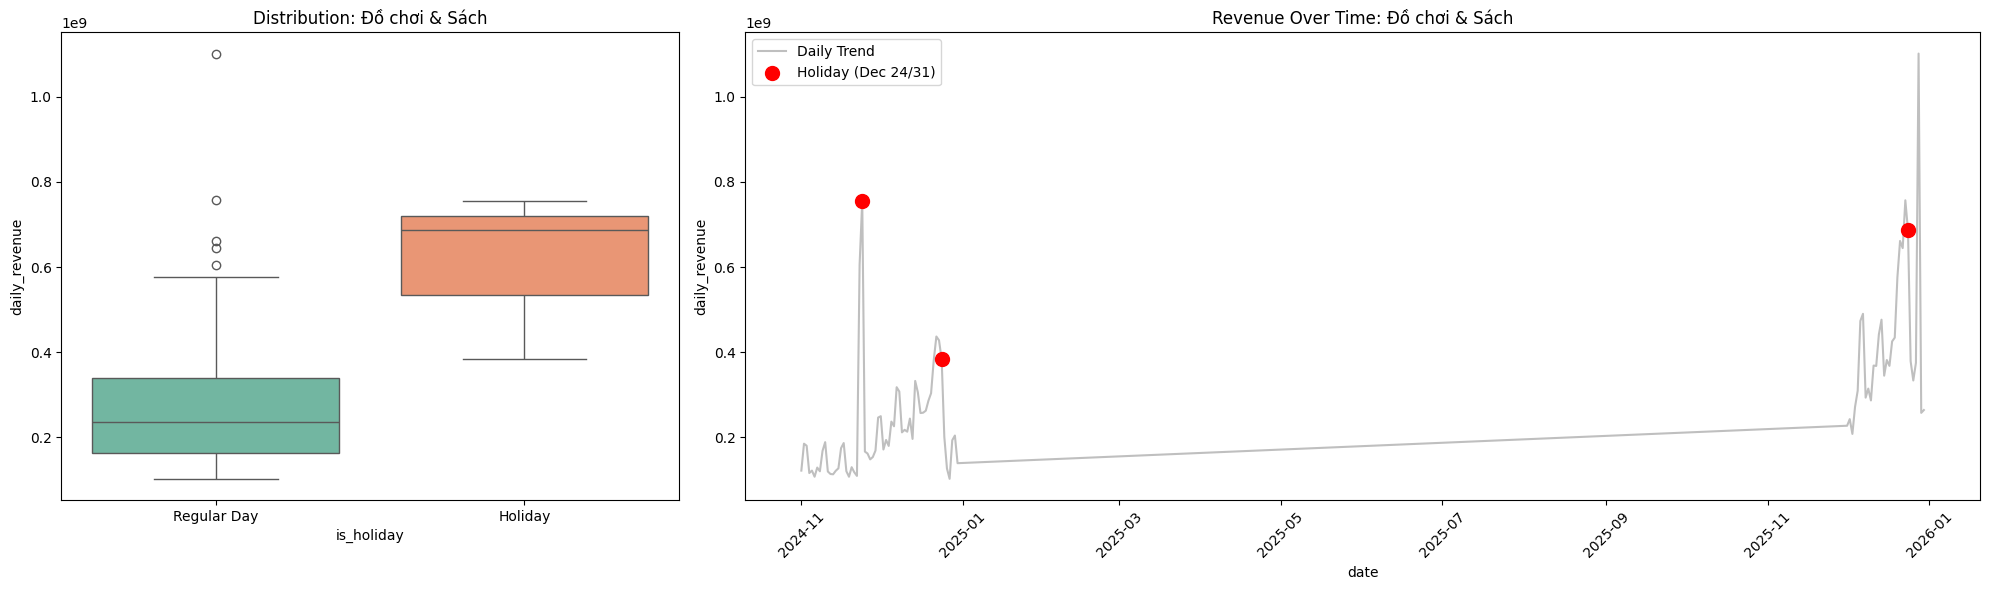


--- Statistical Significance Report for category_l1 ---
Category: Đồ chơi & Sách | P-Value: 0.0047 | Result: SIGNIFICANT

==================== Testing Level: category_l2 ====================


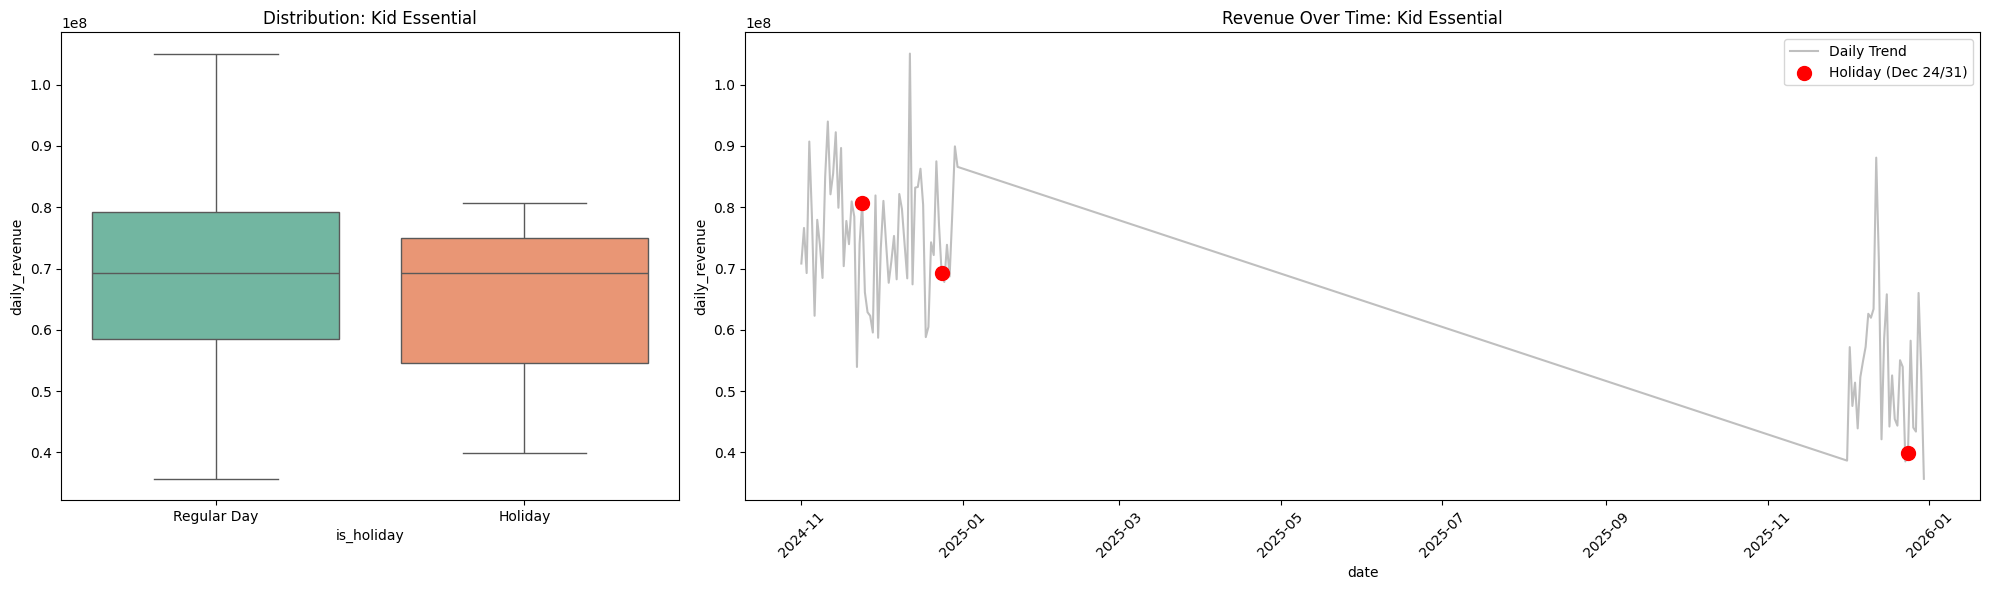


--- Statistical Significance Report for category_l2 ---
Category: Kid Essential | P-Value: 0.7342 | Result: NOT SIGNIFICANT

==================== Testing Level: category ====================


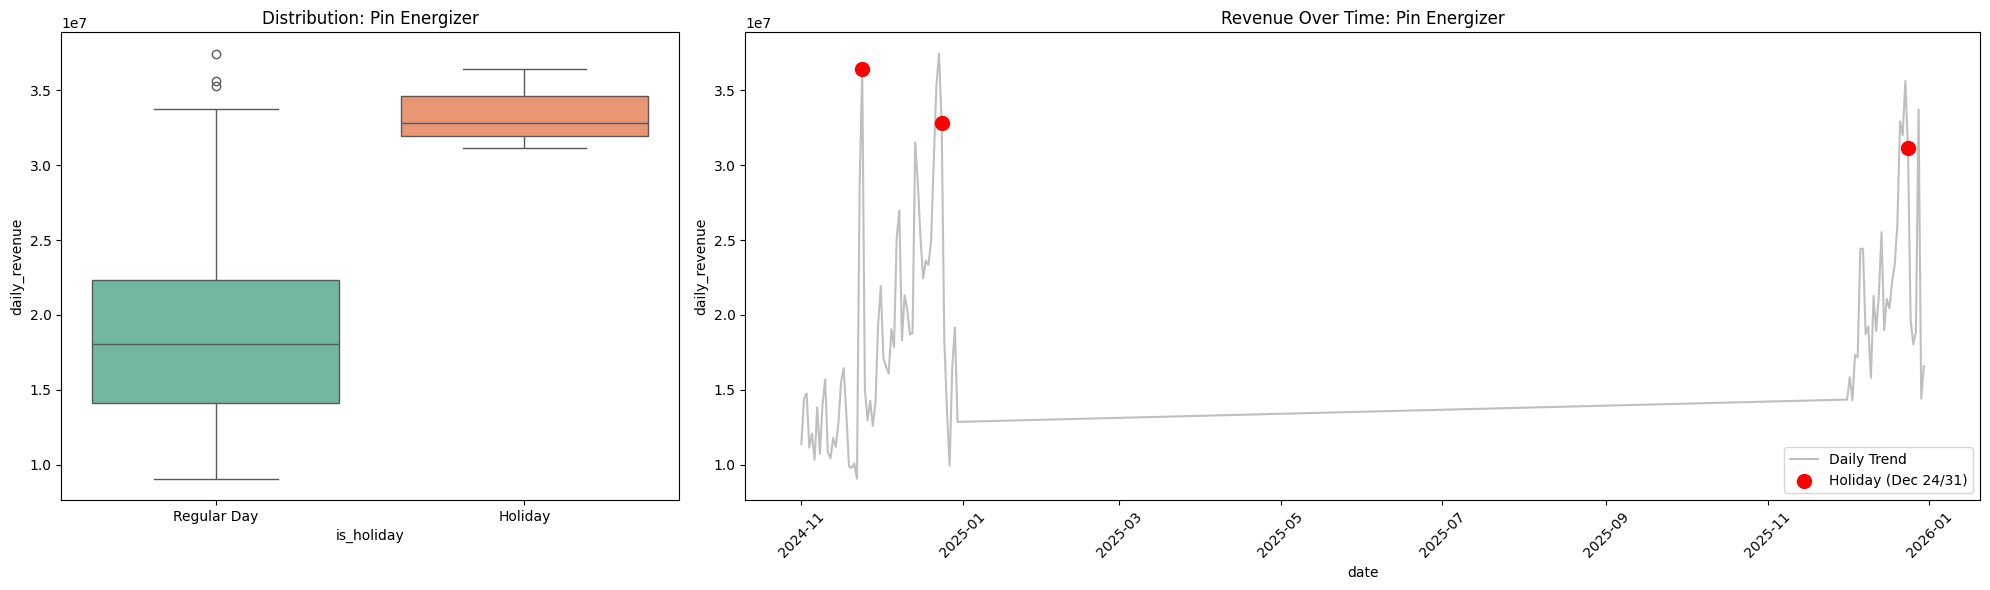


--- Statistical Significance Report for category ---
Category: Pin Energizer | P-Value: 0.0021 | Result: SIGNIFICANT


In [25]:
# List of levels to test
levels = ["category_l1", "category_l2", "category"]

for level in levels:
    print(f"\n{'='*20} Testing Level: {level} {'='*20}")
    level_df = prepare_category_data(df_lf, level)
    report_holiday_impact(level_df, level)